# <a id='toc1_'></a>[C07-C08](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [C07-C08](#toc1_)    
  - [📆 Datenstand](#toc1_1_)    
  - [Datensatz](#toc1_2_)    
  - [Tests](#toc1_3_)    
  - [Histogramme](#toc1_4_)    
  - [🕹️ interactive](#toc1_5_)    
  - [📉 plots](#toc1_6_)    
    - [Rezidive](#toc1_6_1_)    
    - [Verteilung categ_treat](#toc1_6_2_)    
    - [Therapieablauf](#toc1_6_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from pandas_plots import tbl, pls, hlp
from connection_helper import sql
import duckdb as ddb

hlp.show_package_version(["plotly"])
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
# file_db_clin = dir_db/'fake_data_clin.duckdb'

if not file_db_clin.exists():
    raise FileNotFoundError(f"File not found: {file_db_clin}")

🐍 3.12.8 | 📦 plotly: 6.4.0 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.21.3 | 📦 connection-helper: 0.13.1


In [2]:
con = ddb.connect(file_db_clin.as_posix(), read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")
# _=con.execute(f"ATTACH DATABASE '{file_db_clin}' as clin; set schema 'clin';")

## <a id='toc1_1_'></a>[📆 Datenstand](#toc0_)

In [3]:
sql.print_meta(file_db_clin)

sqlite db file:          2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2025-11-11 18:56:55


## <a id='toc1_2_'></a>[Datensatz](#toc0_)

- **Tabellen**
  - `Tumor` - gefiltert
  - `OP` - nur erste pro Tumor
  - `SYST` - nur erste pro Tumor
  - `Bestrahlung` - nur erste pro Tumor
  - `ST` - nur Elemente, die mit den gefilterten `Bestrahlung` verbunden sind 
  - `Folgeereignis` - nur erste pro Tumor

- **nicht-standard Variablen**
  - `categ_treat` - Behandlungskategorie
    - `0_no_op` - keine OP dokumentiert
    - `1_op_not_prim` - OP dokumentiert, aber nicht primär
    - `2_op_st` - primäre OP -> ST _[adjuvant or <=16w]_, danach keine SYST
    - `3_op_st_sy` - primäre OP -> ST -> SYST _[<=30d nach start erste bestrahlung]_
    - `4_op_rest` - primäre OP, restliche Fälle
  - `op_st_period_month` - Zeit OP -> ST in Monaten
  - `st_syst_period_month` - Zeit (erste) Bestrahlung -> SYST
  - `diag_vital_period_month` - Zeit Diagnose -> Vitalstatus in Monaten
  - `diag_follow_period_month` - Zeit Diagnose -> FollowUp in Monaten
  - `fm_locs` - alle dokumentierten FM Lokalisationen eines Folgeereignisses in einem Wert
  - `kkr_has_fo` - true wenn kkr überhaupt Folgeereignisse liefert
  - `has_rez_fo` - true wenn dem Tumor ein Rezidiv über Folgeereignis zugeordnet ist _(>1 Beurteilung)_
  - `has_rez_tnm` - true wenn dem Tumor ein Folgeereignis TNM mit r_symbol zugeordnet ist _(>1 Angabe mit Stadium >0)_

- **Filter**
  - `z_icd10`: C07, C08
  - `z_dy`: 2020 - 2023

- **Metriken**
  - es werden **Tumore** gezählt, jede 1:n Information (z.B. Behandlungen) gibt es nur einmal pro Tumor

In [4]:
FILTER_TUM = """--sql
    z_icd10_3d in ('C07','C08') 
    and z_dy between 2020 and 2023
    """

# print(con.sql("describe SYST"))

In [5]:
# # * 
t_sankey = con.sql("""--sql
    with t1 as (
        select  t.z_tum_id
                ,op.Datum_OP as date_op
                ,Datum_Beginn_SYST as date_sy
                ,Datum_Beginn_Bestrahlung as date_be
        from    Tumor t
        left join OP op on t.z_tum_id = op.z_tum_id
        left join SYST sy on t.z_tum_id = sy.z_tum_id
        left join Bestrahlung be on t.z_tum_id = be.z_tum_id
    ),
    t2 as (
        SELECT  *
        FROM t1
        UNPIVOT (date FOR event IN (date_op AS 'op', date_sy AS 'sy', date_be AS 'be'))
    )
    SELECT  z_tum_id
            ,date
            ,event
            -- this applies AFTER the grouping, so its correct
            --,(count() over (partition by z_tum_id,date order by date) > 1) as has_overlap
    FROM t2
    where date > '1970-01-01'
    -- de-duplicate
    group by z_tum_id, date, event
""")
# tbl.descr_db(t_sankey,"sankey")

In [6]:
# # * find rezidives:
# * 
STADIUMS = "('1', '2', '3', '4')"
t_rez2 = con.sql(f"""--sql
    with t1 as (
        select  z_tum_id
                ,Datum_Folgeereignis
                ,Gesamtbeurteilung_Tumorstatus
                ,Verlauf_Lokaler_Tumorstatus
                ,Verlauf_Tumorstatus_Lymphknoten
                ,Verlauf_Tumorstatus_Fernmetastasen
        from Folgeereignis fo
        where (Gesamtbeurteilung_Tumorstatus = 'Y' or Verlauf_Lokaler_Tumorstatus = 'R' or Verlauf_Tumorstatus_Lymphknoten = 'R' or Verlauf_Tumorstatus_Fernmetastasen = 'R')
        and Datum_Folgeereignis > '1970-01-01'
        -- * select only first event in case >1 meet the criteria
        QUALIFY ROW_NUMBER() over (partition by z_tum_id order by Datum_Folgeereignis) = 1 
        --and count() over (partition by z_tum_id order by Datum_Folgeereignis) > 3
    ),
    t2 as (
        select *
            --distinct z_tum_id
        from Folgeereignis_TNM
        join Folgeereignis on Folgeereignis.FolgeereignisId = Folgeereignis_TNM.FolgeereignisId
        where ((left(T,1) in {STADIUMS}) or (left(N,1) in {STADIUMS}) or (left(M,1) in {STADIUMS})) 
        and Datum_Folgeereignis > '1970-01-01'
        and r_symbol is not null
    ),
    t3 as (
        select tum.z_tum_id
                ,max(t1.z_tum_id is not null) as has_rez_fo
                ,max(t2.z_tum_id is not null) as has_rez_tnm
                ,min(coalesce(t1.Datum_Folgeereignis, t2.Datum_Folgeereignis)) as Datum_Folgeereignis
        from Tumor tum
        left join t1 on tum.z_tum_id = t1.z_tum_id
        left join t2 on tum.z_tum_id = t2.z_tum_id
        where t1.z_tum_id is not null or t2.z_tum_id is not null
        group by tum.z_tum_id
    )
    select * from t3
""")
# tbl.descr_db(t_rez2, "rez2")
# t_rez2.show()

In [7]:
# kategorie behandlung
# - nur primäre op
# - primäre op -> st (adjuvant) or (<=16w)
# - primäre op -> st -> sy (<=30d nach start erste bestrahlung)
# - rest

t_all2 = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id, z_pat_id,

                -- pat
                Verstorben
                ,z_sex

                -- tum
                ,z_kkr_label
                ,(tum.z_kkr not in (1,3,4,10)) as kkr_has_fo
                ,z_icd10
                ,z_dy
                ,Diagnosesicherung
                ,z_t_p_1, z_n_p_1, z_m_p_1
                ,UICC_Stadium_p
                ,Grading
                ,Morphologie_Code
                ,L_p, V_p, Pn_p
                ,z_last_tum_status
                ,z_event_order

                -- dates
                --,Diagnosedatum::date as Diagnosedatum
                --,Datum_OP::date as Datum_OP
                --,Datum_Beginn_Bestrahlung::date as Datum_Beginn_Bestrahlung
                --,Datum_Beginn_SYST::date as Datum_Beginn_SYST
                ,datediff('month', Datum_OP::date, Datum_Beginn_Bestrahlung::date)::int16 as op_st_period_month
                ,datediff('month', Datum_Beginn_Bestrahlung::date, Datum_Beginn_SYST::date)::int16 as st_syst_period_month
                ,datediff('month', Diagnosedatum::date, Datum_Vitalstatus::date)::int16 as diag_vital_period_month
                ,datediff('month', Diagnosedatum::date, fo.Datum_Folgeereignis::date)::int16 as diag_follow_period_month
                
                ,case when has_rez_fo then true else false end as has_rez_fo
                ,case when has_rez_tnm then true else false end as has_rez_tnm
                ,datediff('month', Diagnosedatum::date, t_rez2.Datum_Folgeereignis::date)::int16 as diag_rez_period_month

                -- op
                ,upper(left(Lokale_Beurteilung_Residualstatus,2)) as Lokale_Beurteilung_Residualstatus
                ,Anzahl_Tage_Diagnose_OP

                -- st
                ,st.Stellung_OP as st_stellung_op
                ,st.Intention as st_intention
                ,Anzahl_Tage_Diagnose_ST
                ,Anzahl_Tage_ST_Dauer
                ,regexp_extract(a.TypeOfST_TypBestrahlungApplikationsart,'ST_TypBestrahlungApplikationsart(.+)',1) as Applikationsart
                ,Rate_Type
                ,CodeVersion2014
                ,CodeVersion2021

                -- sy
                ,sy.Intention as syst_intention
                ,sy.Stellung_OP as syst_stellung_op
                ,Therapieart
                ,Anzahl_Tage_Diagnose_SYST
                ,Anzahl_Tage_SYST_Dauer

                -- fo
                ,fo.Gesamtbeurteilung_Tumorstatus
                ,fo.Verlauf_Lokaler_Tumorstatus
                ,fo.Verlauf_Tumorstatus_Lymphknoten
                ,fo.Verlauf_Tumorstatus_Fernmetastasen
                ,fm_locs
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join t_rez2 on tum.z_tum_id = t_rez2.z_tum_id
        left join OP op on tum.z_tum_id = op.z_tum_id and z_op_order = 1
        left join SYST sy on tum.z_tum_id = sy.z_tum_id and z_syst_order = 1
        left join Bestrahlung be on tum.z_tum_id = be.z_tum_id and z_bestr_order = 1
        left join ST st on be.STId = st.STId
        left join (
            select * from Folgeereignis QUALIFY ROW_NUMBER() OVER (PARTITION BY z_tum_id ORDER BY Datum_Folgeereignis ASC) = 1) fo 
        on tum.z_tum_id = fo.z_tum_id 
        left join (
            select FolgeereignisId, STRING_AGG(Lokalisation,'-') as fm_locs
            from Folgeereignis_Fernmetastase
            group by FolgeereignisId) ffm 
        on fo.FolgeereignisId = ffm.FolgeereignisId
        left join Applikationsart a on be.BestrahlungId = a.BestrahlungId
        where {FILTER_TUM}
    ),
    t2 as (
        select  
                -- cat
                case 
                    when STRPOS(z_event_order,'op') = 0 then '0_no_op'
                    when STRPOS(z_event_order,'op') > 1 then '1_op_not_prim'
                    -- only prim op from here
                    when STRPOS(z_event_order,'st') = 4 and STRPOS(z_event_order,'sy') = 0 then '2_op_st'
                    -- possible order: op-st-op-sy
                    when STRPOS(z_event_order,'st') = 4 and STRPOS(z_event_order,'sy') > 4 then '3_op_st_sy'
                    else '4_op_rest' end as categ_treat

                ,case 
                    when STRPOS(z_event_order,'op') = 0 then '0_no_op'
                    when STRPOS(z_event_order,'op') > 1 then '1_op_not_prim'
                    -- only prim op from here
                    when STRPOS(z_event_order,'st') = 4 and (st_stellung_op = 'A' or op_st_period_month between 0 and 4) and STRPOS(z_event_order,'sy') = 0 then '2_op_st'
                    -- possible order: op-st-op-sy
                    when STRPOS(z_event_order,'st') = 4 and STRPOS(z_event_order,'sy') > 4 and st_syst_period_month between 0 and 1 then '3_op_st_sy'
                    else '4_op_rest' end as categ_treat2
                ,* 
        from t1
    )
    select * from t2
""")

# tbl.descr_db(t_all2, "tum")

## <a id='toc1_3_'></a>[Tests](#toc0_)

In [8]:
n_tum_1 = con.sql(f"select count(distinct z_tum_id) from Tumor where {FILTER_TUM}").fetchone()[0]
n_tum_2 = con.sql("select count(*) from t_all2").fetchone()[0]
assert n_tum_1 == n_tum_2,f"❌ tum count wrong: {n_tum_1} vs {n_tum_2}"
print(f"✅ tum count ok {n_tum_1:_}")

✅ tum count ok 4_367


In [9]:
if False:
    (con.sql("""select * 
            from t_all2 
            where categ_treat <> categ_treat2
            --where z_tum_id = 'f0857d3a-1dea-4165-95bc-68d42f6b232e'
        """)
        # .limit(1)
        .show()
    )
if False:
    _id = '185139ce-14dd-4863-8ff5-854673965aaa'
    con.sql(f"""select * from t_all2 where z_tum_id = '{_id}'""").show()
    con.sql(f"""select Diagnosedatum from Tumor where z_tum_id = '{_id}'""").show()
    con.sql(f"""select * from OP where z_tum_id = '{_id}' order by Datum_OP""").show()
    con.sql(f"""select * from OPS where z_tum_id = '{_id}'""").show()
    con.sql(f"""select * from ST where z_tum_id = '{_id}'""").show()
    con.sql(f"""select * from Bestrahlung where z_tum_id = '{_id}' order by Datum_Beginn_Bestrahlung""").show()
    con.sql(f"""select * from SYST where z_tum_id = '{_id}' order by Datum_Beginn_SYST""").show()
    con.sql(f"""select * from Folgeereignis where z_tum_id = '{_id}' order by Datum_Folgeereignis""").show()
    con.sql(f"""select * from Folgeereignis_TNM where z_tum_id = '{_id}'""").show()

## <a id='toc1_4_'></a>[Histogramme](#toc0_)

🔵 *** df: tum ***  
🟣 shape: (4_367, 47)
🟣 duplicates: 92  
🟠 column stats all (dtype | uniques | missings) [values]  
- index [0, 1, 2, 3, 4,]  
- categ_treat (object | 5 | 0 (0%)) ['0_no_op', '1_op_not_prim', '2_op_st', '3_op_st_sy', '4_op_rest',]  
- categ_treat2 (object | 5 | 0 (0%)) ['0_no_op', '1_op_not_prim', '2_op_st', '3_op_st_sy', '4_op_rest',]  
- Verstorben (object | 2 | 0 (0%)) ['J', 'N',]  
- z_sex (object | 2 | 0 (0%)) ['M', 'W',]  
- z_kkr_label (object | 16 | 0 (0%)) ['01-SH', '02-HH', '03-NI', '04-HB', '05-NW',]  
- kkr_has_fo (bool | 2 | 0 (0%)) [False, True,]  
- z_icd10 (object | 5 | 0 (0%)) ['C07', 'C08.0', 'C08.1', 'C08.8', 'C08.9',]  
- z_dy (int16 | 4 | 0 (0%)) [2020, 2021, 2022, 2023,]  
- Diagnosesicherung (object | 7 | 0 (0%)) ['0', '1', '2', '5', '6',]  
- z_t_p_1 (object | 7 | 1_407 (32%)) ['0', '1', '2', '3', '4',]  
- z_n_p_1 (object | 6 | 1_626 (37%)) ['0', '1', '2', '3', '<NA>',]  
- z_m_p_1 (object | 3 | 2_367 (54%)) ['0', '1', '<NA>',]  
- UICC_Stadi

,categ_treat,categ_treat2,Verstorben,z_sex,z_kkr_label,kkr_has_fo,z_icd10,z_dy,Diagnosesicherung,z_t_p_1,...,syst_intention,syst_stellung_op,Therapieart,Anzahl_Tage_Diagnose_SYST,Anzahl_Tage_SYST_Dauer,Gesamtbeurteilung_Tumorstatus,Verlauf_Lokaler_Tumorstatus,Verlauf_Tumorstatus_Lymphknoten,Verlauf_Tumorstatus_Fernmetastasen,fm_locs
0,4_op_rest,4_op_rest,N,M,05-NW,True,C08.0,2023,7,3,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,4_op_rest,4_op_rest,N,M,09-BY,True,C07,2020,7,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,4_op_rest,4_op_rest,N,M,09-BY,True,C07,2022,7,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


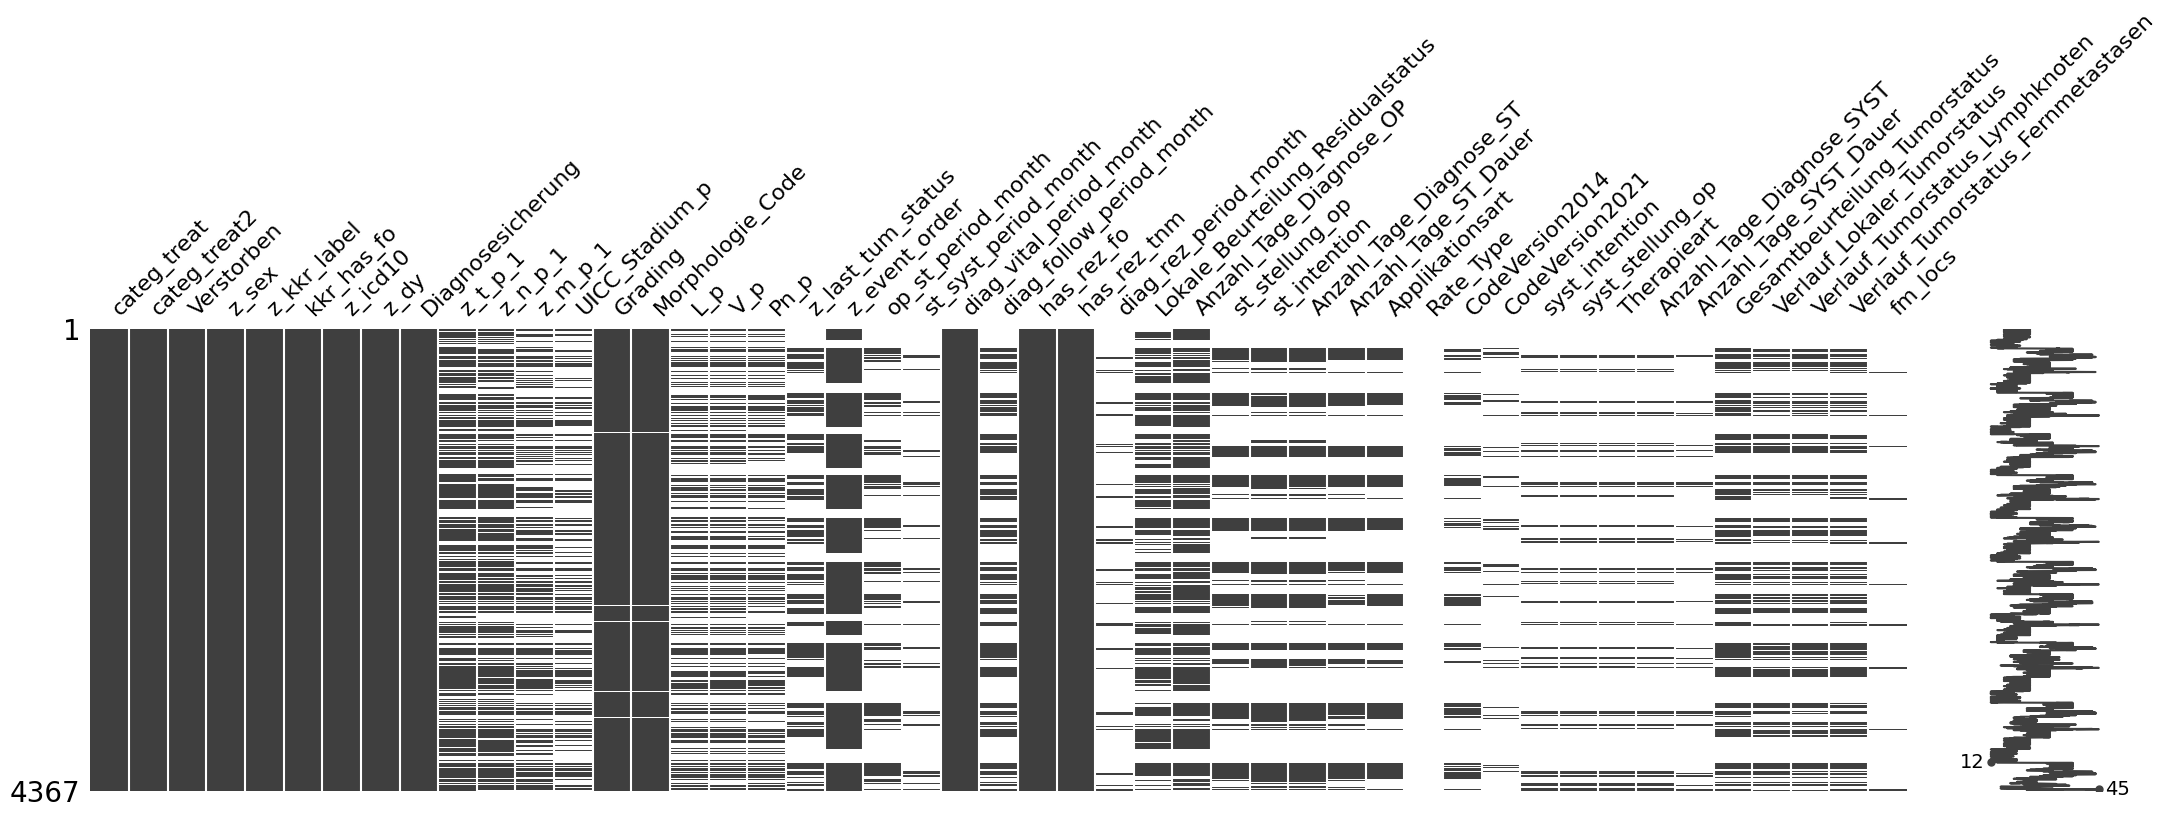

In [10]:
tbl.describe_df(t_all2
            .project("* exclude(z_tum_id, z_pat_id)")
            .to_df(), "tum", use_missing=True, fig_cols=5)

## <a id='toc1_5_'></a>[🕹️ interactive](#toc0_)

In [11]:
df_pivot = t_all2.to_df()

In [12]:
if False:
    import pygwalker as pyg

    spec="config/pygwalker_spec_c07.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[
                                ("cnt_pat", "count(distinct z_pat_id)"), 
                                ])

    _=pyg.walk(df_pivot, kernel_computation=True, spec=spec)

## <a id='toc1_6_'></a>[📉 plots](#toc0_)

### <a id='toc1_6_1_'></a>[Rezidive](#toc0_)
- Filter: 
  - Tumorfälle aus kkr die Folgeereignisse liefern 
  - Tumor hat `R0` zugeordnet
 

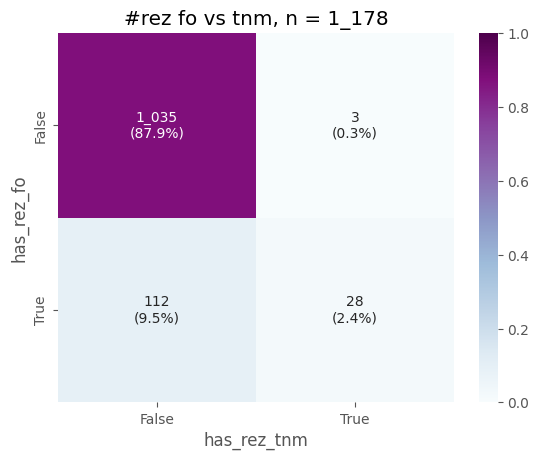

In [13]:
_df = (t_all2
    .filter("kkr_has_fo")
    .filter("Lokale_Beurteilung_Residualstatus = 'R0'")
    .project("has_rez_fo, has_rez_tnm")
    .to_df()
)

_=pls.plot_quadrants(_df, caption="rez fo vs tnm")

### <a id='toc1_6_2_'></a>[Verteilung categ_treat](#toc0_)

In [14]:
pls.plot_stacked_bars(
    con.sql("select z_kkr_label, categ_treat from t_all2").to_df(),
    swap=False,
    orientation="h",
    height=600,
    show_pct_bar=True,
    relative=True,
    show_total=True,
)

### <a id='toc1_6_3_'></a>[Therapieablauf](#toc0_)
- abgebildet ist die Verteilung der Tumorfälle auf Therapien
- Therapien = die ersten 5 OP / SYST / Bestrahlung im Zeitablauf

In [15]:
_db = (t_sankey
    .join(t_all2, "z_tum_id", "inner")
    .project("z_tum_id, date, event")
)
_df = _db.to_df()
# tbl.descr_db(_db)

In [16]:
pls.plot_sankey(_df, max_events_per_id=5, exclude_overlap_id=True,height=750, width=1600)